#  Problem Statement:
Use a relevant machine learinig model to predict whether person has heart disease or not

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns

In [2]:
data = pd.read_csv("/content/labels.csv")

In [3]:
data

,patient_id,heart_disease_present
0,0z64un,0
1,ryoo3j,0
2,yt1s1x,1
3,l2xjde,1
4,oyt4ek,0
...,...,...
175,5qfar3,1
176,2s2b1f,1
177,nsd00i,1
178,0xw93k,0


In [4]:
data1=pd.read_csv("/content/values.csv")

In [5]:
data1

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0


In [6]:
df_data = data1.merge(data, on="patient_id", how = 'inner')

# Domain Analysis

Heart disease is the leading cause of death globally.
Early prediction helps prevent serious health issues by identifying high-risk individuals and
providing timely medical intervention.

Input variable:

1)Age & Sex: Older age and male gender increase the risk.

2)Chest Pain: Different types of chest pain can indicate heart issues.

3)Blood Pressure: High blood pressure is a major risk factor.

4)cholesterol: High cholesterol can block arteries, leading to heart problems.

5)Blood Sugar: High sugar levels are linked to diabetes and heart disease.

6)Heart Rate: Low heart rate during exercise may signal heart issues.

7)Angina: Chest pain during physical activity suggests potential heart disease.

8)ECG Results: Abnormal heart rhythms are red flags for heart disease.


9)num_major_vessels: High number of major vessels can indicate heart disease.


output variable:

Prediction: Presence or absence of heart disease.

In [7]:
df_data

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0


In [8]:
df_data.rename(columns={'heart_disease_present':'HeartDisease',
                        'slope_of_peak_exercise_st_segment':'ST_Slope',
                        'resting_blood_pressure':'RestingBP',
                        'chest_pain_type':'ChestPainType',
                        'fasting_blood_sugar_gt_120_mg_per_dl':'FastingBS',
                        'resting_ekg_results':'RestingECG',
                        'num_major_vessels':'NumMajoredVessels',
                        'serum_cholesterol_mg_per_dl':'Cholesterol',
                        'oldpeak_eq_st_depression':'Oldpeak'  ,
                        'max_heart_rate_achieved':'MaxHR',
                        'exercise_induced_angina':'ExerciseAngina'} ,inplace=True)


## Basic checks

In [9]:
df_data.shape

(180, 15)

In [10]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patient_id         180 non-null    object 
 1   ST_Slope           180 non-null    int64  
 2   thal               180 non-null    object 
 3   RestingBP          180 non-null    int64  
 4   ChestPainType      180 non-null    int64  
 5   NumMajoredVessels  180 non-null    int64  
 6   FastingBS          180 non-null    int64  
 7   RestingECG         180 non-null    int64  
 8   Cholesterol        180 non-null    int64  
 9   Oldpeak            180 non-null    float64
 10  sex                180 non-null    int64  
 11  age                180 non-null    int64  
 12  MaxHR              180 non-null    int64  
 13  ExerciseAngina     180 non-null    int64  
 14  HeartDisease       180 non-null    int64  
dtypes: float64(1), int64(12), object(2)
memory usage: 21.2+ KB


In [11]:
df_data.columns

Index(['patient_id', 'ST_Slope', 'thal', 'RestingBP', 'ChestPainType',
       'NumMajoredVessels', 'FastingBS', 'RestingECG', 'Cholesterol',
       'Oldpeak', 'sex', 'age', 'MaxHR', 'ExerciseAngina', 'HeartDisease'],
      dtype='object')

In [12]:
df_data.describe().T

,count,mean,std,min,25%,50%,75%,max
ST_Slope,180.0,1.550000,0.618838,1.0,1.00,1.0,2.00,3.0
RestingBP,180.0,131.311111,17.010443,94.0,120.00,130.0,140.00,180.0
ChestPainType,180.0,3.155556,0.938454,1.0,3.00,3.0,4.00,4.0
NumMajoredVessels,180.0,0.694444,0.969347,0.0,0.00,0.0,1.00,3.0
FastingBS,180.0,0.161111,0.368659,0.0,0.00,0.0,0.00,1.0
RestingECG,180.0,1.050000,0.998742,0.0,0.00,2.0,2.00,2.0
Cholesterol,180.0,249.211111,52.717969,126.0,213.75,245.5,281.25,564.0
Oldpeak,180.0,1.010000,1.121357,0.0,0.00,0.8,1.60,6.2
sex,180.0,0.688889,0.464239,0.0,0.00,1.0,1.00,1.0
age,180.0,54.811111,9.334737,29.0,48.00,55.0,62.00,77.0


In [13]:
df_data.describe(include="O")

,patient_id,thal
count,180,180
unique,180,3
top,0z64un,normal
freq,1,98


In [14]:
df_data.head(5)

,patient_id,ST_Slope,thal,RestingBP,ChestPainType,NumMajoredVessels,FastingBS,RestingECG,Cholesterol,Oldpeak,sex,age,MaxHR,ExerciseAngina,HeartDisease
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [15]:
df_data.tail(5)

,patient_id,ST_Slope,thal,RestingBP,ChestPainType,NumMajoredVessels,FastingBS,RestingECG,Cholesterol,Oldpeak,sex,age,MaxHR,ExerciseAngina,HeartDisease
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0
179,2nx10r,1,normal,160,3,1,0,0,201,0.0,0,54,163,0,0


In [16]:
df_data.dtypes

,0
patient_id,object
ST_Slope,int64
thal,object
RestingBP,int64
ChestPainType,int64
NumMajoredVessels,int64
FastingBS,int64
RestingECG,int64
Cholesterol,int64
Oldpeak,float64


In [17]:
df_data.thal.unique()

array(['normal', 'reversible_defect', 'fixed_defect'], dtype=object)

# **EDA**

In [18]:
## Univariate Analysis
!pip install sweetviz

In [19]:
# library for univariate analysis
#import sweetviz as sv
#my_report = sv.analyze(df_data)
#my_report.show_html() # Default argument will generate to "SWEETVIZ_REPORT.html"

### Insights
- RestingECG feature is categorical with three distinct categories, with category 2 being the most prevalent. The low count in category 1 suggests a potential imbalance that might need to be considered during model training.
-  Cholesterol feature exhibits a right-skewed distribution with a wide range of values. The high kurtosis and skewness indicate the presence of outliers. The mean and median are relatively close, but the skewness suggests that the mean is influenced by the higher values.
-  Oldpeak feature is right-skewed, with a large proportion of zero values. The mean is slightly higher than the median, which is typical for right-skewed data. The presence of a significant number of zeros might indicate a specific characteristic of the dataset that needs further investigation.
-  Sex feature is a binary categorical variable, representing male and female patients. The distribution shows the ratio of male to female patients.
- Thal feature has three categories: normal, reversible defect & fixed defect, with 'reversible defect' being the most common. This feature is likely important for predicting heart disease and needs further analysis to understand its relationship with the target variable.
-  age feature is reasonably well-distributed, with a slight left skew. The mean and median are very close, indicating a roughly symmetrical distribution. The age range is from 29 to 77 years.
-  MaxHR feature is somewhat left-skewed, with a higher concentration of values towards the higher end of the range. The median is slightly higher than the mean, which is typical for a left-skewed distribution.
-  ExerciseAngina feature is a binary categorical variable, indicating whether a patient experiences angina during exercise. The distribution shows the ratio of patients with and without exercise-induced angina.
-  HeartDisease feature is the target variable, a binary categorical variable indicating the presence or absence of heart disease. The report also shows the most frequent ages within the dataset.
-  RestingBP feature exhibits a slightly right-skewed distribution. The mean and median are close, indicating a relatively symmetrical distribution with a slight positive skew. The range of resting blood pressure is from 94 to 180.
-  ChestPainType feature is a categorical variable with four distinct categories. The distribution shows the frequency of each chest pain type. Further analysis is needed to understand how each category relates to heart disease.
-  NumMajoredVessels feature is a categorical variable with four distinct categories. The distribution shows the frequency of each number of major vessels. Further analysis is needed to understand how each category relates to heart disease.
-  FastingBS feature is a binary categorical variable, indicating whether a patient's fasting blood sugar is above a certain threshold. The distribution shows the ratio of patients with and without elevated fasting blood sugar.-  NumMajoredVessels feature is a categorical variable with four distinct categories. The distribution shows the frequency of each number of major vessels. Further analysis is needed to understand how each category relates to heart disease.
-  FastingBS feature is a binary categorical variable, indicating whether a patient's fasting blood sugar is above a certain threshold. The distribution shows the ratio of patients with and without elevated fasting blood sugar.

In [20]:
# Bivarate Analysis
num_col=df_data.select_dtypes(include=['int64','float64']).columns
num_col

Index(['ST_Slope', 'RestingBP', 'ChestPainType', 'NumMajoredVessels',
       'FastingBS', 'RestingECG', 'Cholesterol', 'Oldpeak', 'sex', 'age',
       'MaxHR', 'ExerciseAngina', 'HeartDisease'],
      dtype='object')

In [21]:
cat_col=df_data.select_dtypes(include=['object']).columns
cat_col

Index(['patient_id', 'thal'], dtype='object')

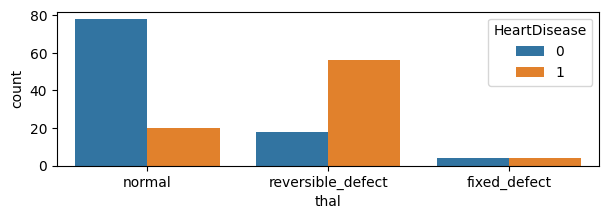

In [22]:
## For the categorical data(thal)
plt.figure(figsize=(7,2))
sns.countplot(data=df_data,x='thal',hue='HeartDisease')
plt.show()

# **INSIGHTS**

1)For normal -thal patients ,nearly 70% - have no heart disease

2)For Reversible defect -the highest risk of heart disease

3)For fixed defect , both heart and non heart disease seems to have balanced distribution of heart disease




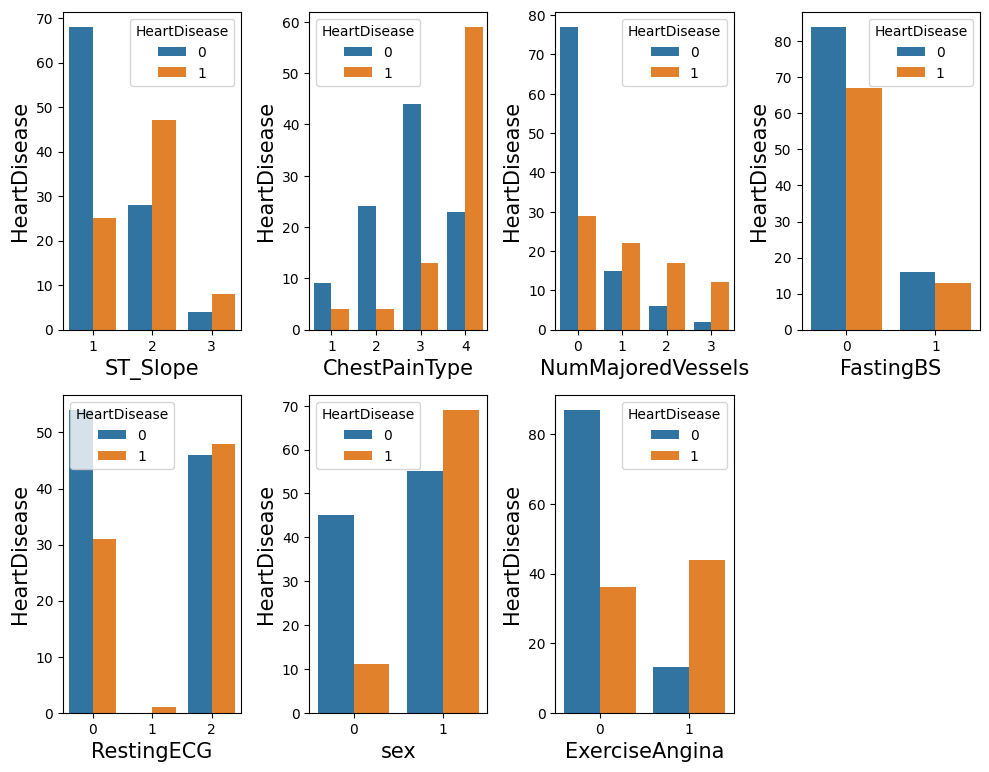

In [23]:
dis_col=df_data[['ST_Slope', 'ChestPainType','NumMajoredVessels', 'FastingBS', 'RestingECG', 'sex',   'ExerciseAngina']]
#creating count for discrete columns
plt.figure(figsize=(10,15))
plotnumber=1
for i in dis_col:
  if plotnumber<=7:
    plt.subplot(4,4,plotnumber)
    sns.countplot(data=dis_col,x=dis_col[i],hue=df_data.HeartDisease)
    plt.xlabel(i,fontsize=15)
    plt.ylabel('HeartDisease',fontsize=15)
    plotnumber+=1
plt.tight_layout()

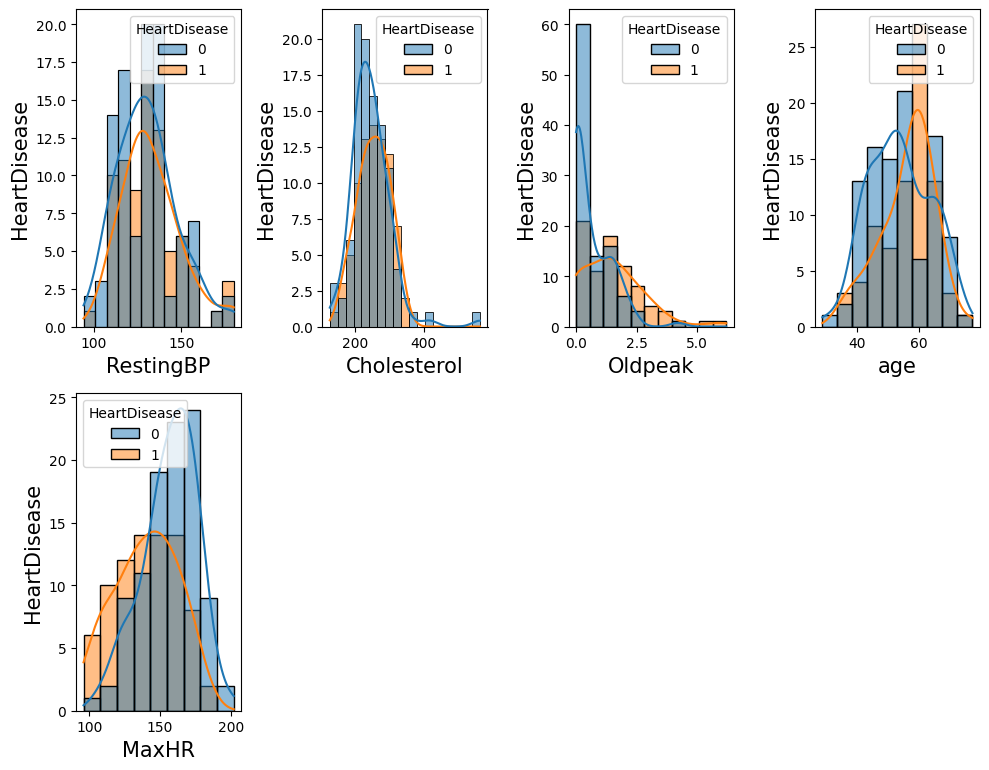

In [24]:
cont_col=df_data[[ 'RestingBP','Cholesterol', 'Oldpeak', 'age', 'MaxHR']]
#creating histplot for numerical columns
plt.figure(figsize=(10,15))
plotnumber=1
for i in cont_col:
  if plotnumber<=7:
    plt.subplot(4,4,plotnumber)
    sns.histplot(x=cont_col[i],hue=df_data.HeartDisease,kde=True)
    plt.xlabel(i,fontsize=15)
    plt.ylabel('HeartDisease',fontsize=15)
    plotnumber+=1
plt.tight_layout()

# **INSIGHTS**
# 1)RestingBP:
 Range between 120-140,the chance of heart disease is low. People with heart disease tend to have slightly higher blood pressure, but there is significant overlap with those without heart disease,so high BP alone may not be a strong indicator of heart disease.
# 2)Cholesterol:
Range between 200-300 , the chance of heart disease is low.slightly wider range of cholesterol levels has heart disease but again there is overlap with those without heart disease, like BP cholesterol also not strong indicator of heart disease.
# 3)Oldpeak:
 For Above 1, the chance of heart disease is high.at lower rate chances of heart disease are very less
# 4)Age:
For Age below 60 the chance disease is low and above the age 60  then the chance of heart disease is high.
# 5)MaxHR
 For Range Above 150-Heart Disease-very less Chance,Below 150 -high chance


In [25]:
df_data1=df_data.copy()
df_data1

,patient_id,ST_Slope,thal,RestingBP,ChestPainType,NumMajoredVessels,FastingBS,RestingECG,Cholesterol,Oldpeak,sex,age,MaxHR,ExerciseAngina,HeartDisease
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0


In [26]:
df_data1.drop('patient_id',axis=1,inplace=True)

In [27]:
df_data1

,ST_Slope,thal,RestingBP,ChestPainType,NumMajoredVessels,FastingBS,RestingECG,Cholesterol,Oldpeak,sex,age,MaxHR,ExerciseAngina,HeartDisease
0,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0


# **Data preprocessing**

In [28]:
#checking for isnull values
df_data1.isnull().sum()

,0
ST_Slope,0
thal,0
RestingBP,0
ChestPainType,0
NumMajoredVessels,0
FastingBS,0
RestingECG,0
Cholesterol,0
Oldpeak,0
sex,0


In [29]:
# Check for duplicates
df_data1.duplicated().sum()

np.int64(0)

# **Checking for Outliers**

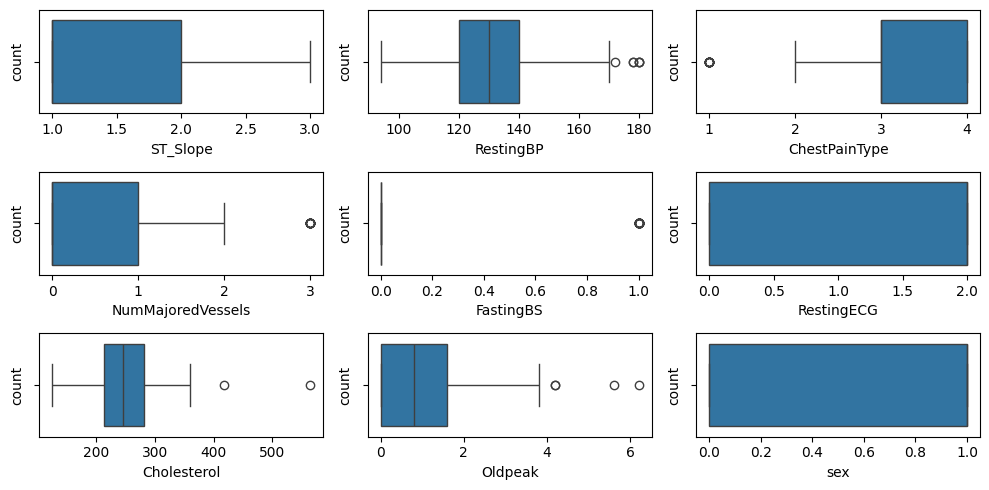

In [30]:
#creating boxplot for numerical columns
plt.figure(figsize=(10,5),facecolor='white')# to change the length and breadth of the canva
plotnumber=1
for i in df_data1.drop(columns=['HeartDisease','thal'],axis=1):
    if plotnumber<=9:
        ax=plt.subplot(3,3,plotnumber)
        sns.boxplot(x=df_data1[i])
        plt.xlabel(i,fontsize=10)
        plt.ylabel("count",fontsize=10)
        plotnumber+=1
    plt.tight_layout() # without this there is overlapping

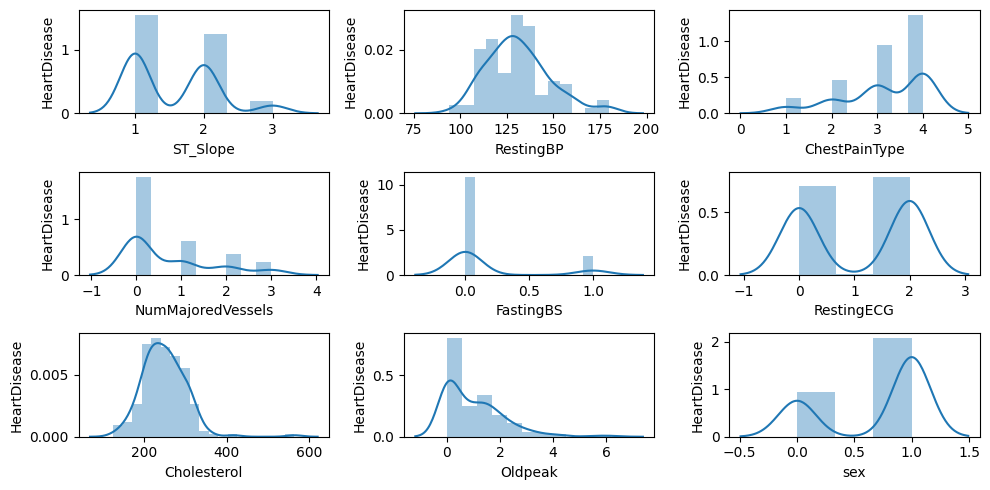

In [31]:
#creating distplot for numerical columns to know which rule to use whether IQR or 3 sigma
plt.figure(figsize=(10,5),facecolor='white')# to change the length and breadth of the canva
plotnumber=1
for i in df_data1.drop(columns=['HeartDisease','thal'],axis=1):
    if plotnumber<=9:
        ax=plt.subplot(3,3,plotnumber)
        sns.distplot(x=df_data1[i])
        plt.xlabel(i,fontsize=10)
        plt.ylabel("HeartDisease",fontsize=10)
        plotnumber+=1
    plt.tight_layout()


# **HANDLING OUTLIERS**

In [32]:
# Handling Outliers
Q1=df_data1['RestingBP'].quantile(0.25)
print("lower quartile",Q1)
Q3=df_data1['RestingBP'].quantile(0.75)
print('upper quartile',Q3)

lower quartile 120.0
upper quartile 140.0


In [33]:
# Find IQR
IQR=Q3-Q1
IQR

np.float64(20.0)

In [34]:
lower_limit=Q1-1.5*IQR
print("lower limit is",lower_limit)
upper_limit=Q3+1.5*IQR
print("upper_limit",upper_limit)

lower limit is 90.0
upper_limit 170.0


In [35]:
# Find values above upper_limit
df_data1.loc[df_data1['RestingBP']>upper_limit]

,ST_Slope,thal,RestingBP,ChestPainType,NumMajoredVessels,FastingBS,RestingECG,Cholesterol,Oldpeak,sex,age,MaxHR,ExerciseAngina,HeartDisease
4,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0
33,1,normal,180,4,0,0,0,325,0.0,0,64,154,1,0
72,1,reversible_defect,172,3,0,1,0,199,0.5,1,52,162,0,0
75,2,reversible_defect,178,4,2,1,0,228,1.0,0,66,165,1,1
113,2,reversible_defect,180,3,0,1,2,274,1.6,1,68,150,1,1
176,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1


In [36]:
# Find percentage of outliers
len(df_data1.loc[df_data1['RestingBP']>upper_limit])/len(data)

0.03333333333333333

In [37]:
# Find values below lower_limits
df_data1.loc[df_data1['RestingBP']<lower_limit]

,ST_Slope,thal,RestingBP,ChestPainType,NumMajoredVessels,FastingBS,RestingECG,Cholesterol,Oldpeak,sex,age,MaxHR,ExerciseAngina,HeartDisease


In [38]:
df_data1.loc[df_data1['RestingBP']>upper_limit,"RestingBP"]=df_data1['RestingBP'].median()

<Axes: xlabel='RestingBP'>

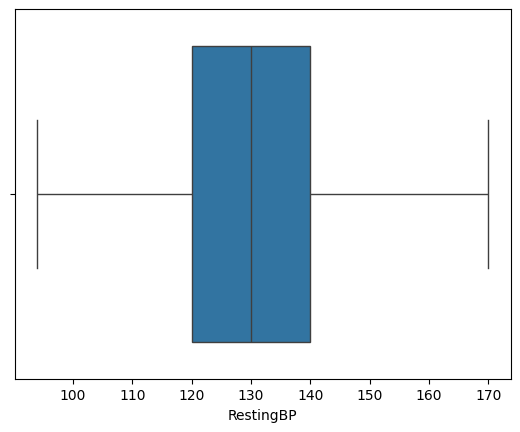

In [39]:
# check are there any outliers in Resting Bp
sns.boxplot(x=df_data1.RestingBP)

In [40]:
# Handling Outliers
Q1=df_data1['ChestPainType'].quantile(0.25)
print("lower quartile",Q1)
Q3=df_data1['ChestPainType'].quantile(0.75)
print('upper quartile',Q3)

lower quartile 3.0
upper quartile 4.0


In [41]:
# Find IQR
IQR=Q3-Q1
IQR

np.float64(1.0)

In [42]:
# find  Lower limits and upper limit
lower_limit=Q1-1.5*IQR
print("lower limit is",lower_limit)
upper_limit=Q3+1.5*IQR
print("upper_limit",upper_limit)

lower limit is 1.5
upper_limit 5.5


In [43]:
#Find values above upper_limit
df_data1.loc[df_data1['ChestPainType']>upper_limit]

,ST_Slope,thal,RestingBP,ChestPainType,NumMajoredVessels,FastingBS,RestingECG,Cholesterol,Oldpeak,sex,age,MaxHR,ExerciseAngina,HeartDisease


In [44]:
# Find percentage of outliers
len(df_data1.loc[df_data1['ChestPainType']>upper_limit])/len(data)

0.0

In [45]:
# Find values below lower_limits
df_data1.loc[df_data1['ChestPainType']<lower_limit]

,ST_Slope,thal,RestingBP,ChestPainType,NumMajoredVessels,FastingBS,RestingECG,Cholesterol,Oldpeak,sex,age,MaxHR,ExerciseAngina,HeartDisease
4,3,reversible_defect,130,1,0,0,2,270,4.2,1,59,145,0,0
14,2,reversible_defect,120,1,0,0,0,231,3.8,1,38,182,1,1
97,2,normal,160,1,1,1,2,234,0.1,1,69,131,0,0
99,1,normal,150,1,0,1,2,283,1.0,0,58,162,0,0
108,1,normal,125,1,1,0,2,213,1.4,1,51,125,1,0
120,2,normal,138,1,1,1,2,282,1.4,1,65,174,0,1
141,2,reversible_defect,120,1,0,0,2,193,1.9,1,56,162,0,0
146,1,reversible_defect,140,1,0,0,0,199,1.4,1,40,178,1,0
147,2,normal,134,1,2,0,0,234,2.6,1,61,145,0,1
155,1,normal,160,1,0,0,2,273,0.0,1,59,125,0,1


In [46]:
df_data1.loc[df_data1['ChestPainType']>upper_limit,"ChestPainType"]=df_data1['ChestPainType'].median()

<Axes: xlabel='ChestPainType'>

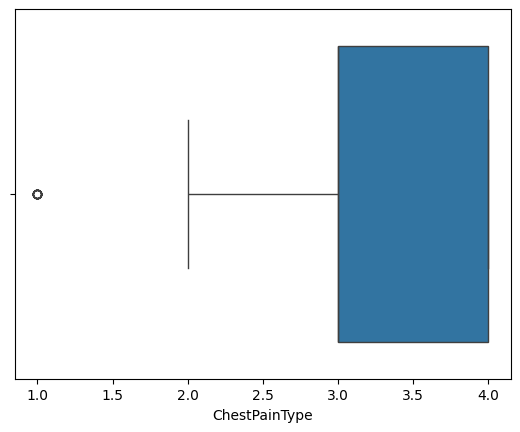

In [47]:
# check are there any outliers in Resting Bp
sns.boxplot(x=df_data1.ChestPainType)

In [48]:
# Handling Outliers
Q1=df_data1['NumMajoredVessels'].quantile(0.25)
print("lower quartile",Q1)
Q3=df_data1['NumMajoredVessels'].quantile(0.75)
print('upper quartile',Q3)

lower quartile 0.0
upper quartile 1.0


In [49]:
# Find IQR
IQR=Q3-Q1
IQR

np.float64(1.0)

In [50]:
# find  Lower limits and upper limit
lower_limit=Q1-1.5*IQR
print("lower limit is",lower_limit)
upper_limit=Q3+1.5*IQR
print("upper_limit",upper_limit)

lower limit is -1.5
upper_limit 2.5


In [51]:
#Find values above upper_limit
df_data1.loc[df_data1['NumMajoredVessels']>upper_limit]

,ST_Slope,thal,RestingBP,ChestPainType,NumMajoredVessels,FastingBS,RestingECG,Cholesterol,Oldpeak,sex,age,MaxHR,ExerciseAngina,HeartDisease
2,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
21,1,reversible_defect,108,4,3,1,0,233,0.1,1,52,147,0,0
31,2,reversible_defect,150,4,3,0,2,225,1.0,0,65,114,0,1
52,1,reversible_defect,130,4,3,1,2,330,1.8,1,63,132,1,1
66,2,normal,130,4,3,0,2,322,2.4,1,70,109,0,1
69,2,reversible_defect,120,3,3,0,0,188,2.0,1,49,139,0,1
85,1,normal,118,3,3,0,2,149,0.8,1,49,126,0,1
112,2,reversible_defect,140,4,3,0,0,298,4.2,1,51,122,1,1
119,2,normal,138,4,3,1,0,294,1.9,0,62,106,0,1
123,1,normal,130,3,3,1,2,246,0.0,1,53,173,0,0


In [52]:
# Find percentage of outliers
len(df_data1.loc[df_data1['NumMajoredVessels']>upper_limit])/len(data)

0.07777777777777778

In [53]:
# Find values below lower_limits
df_data1.loc[df_data1['NumMajoredVessels']<lower_limit]

,ST_Slope,thal,RestingBP,ChestPainType,NumMajoredVessels,FastingBS,RestingECG,Cholesterol,Oldpeak,sex,age,MaxHR,ExerciseAngina,HeartDisease


In [54]:
df_data1.loc[df_data1['NumMajoredVessels']>upper_limit,"NumMajoredVessels"]=df_data1['NumMajoredVessels'].median()

<Axes: xlabel='NumMajoredVessels'>

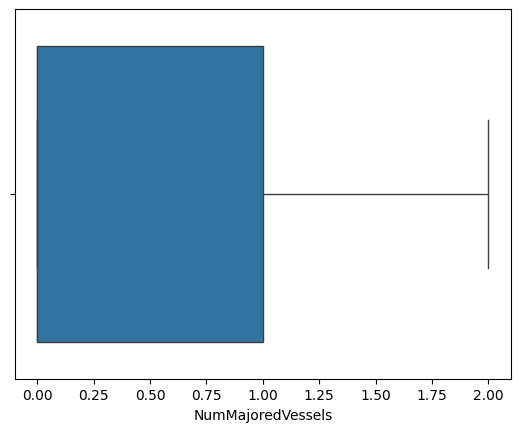

In [55]:

# check are there any outliers in Resting Bp
sns.boxplot(x=df_data1.NumMajoredVessels)

In [56]:
# Handling Outliers
Q1=df_data1['Cholesterol'].quantile(0.25)
print("lower quartile",Q1)
Q3=df_data1['Cholesterol'].quantile(0.75)
print('upper quartile',Q3)

lower quartile 213.75
upper quartile 281.25


In [57]:
# Find IQR
IQR=Q3-Q1
IQR

np.float64(67.5)

In [58]:
# find  Lower limits and upper limit
lower_limit=Q1-1.5*IQR
print("lower limit is",lower_limit)
upper_limit=Q3+1.5*IQR
print("upper_limit",upper_limit)

lower limit is 112.5
upper_limit 382.5


In [59]:
#Find values above upper_limit
df_data1.loc[df_data1['Cholesterol']>upper_limit]

,ST_Slope,thal,RestingBP,ChestPainType,NumMajoredVessels,FastingBS,RestingECG,Cholesterol,Oldpeak,sex,age,MaxHR,ExerciseAngina,HeartDisease
43,1,normal,140,3,1,1,2,417,0.8,0,65,157,0,0
60,2,reversible_defect,115,3,0,0,2,564,1.6,0,67,160,0,0


In [60]:
# Find percentage of outliers
len(df_data1.loc[df_data1['Cholesterol']>upper_limit])/len(data)

0.011111111111111112

In [61]:
# Find values below lower_limits
df_data1.loc[df_data1['Cholesterol']<lower_limit]

,ST_Slope,thal,RestingBP,ChestPainType,NumMajoredVessels,FastingBS,RestingECG,Cholesterol,Oldpeak,sex,age,MaxHR,ExerciseAngina,HeartDisease


In [62]:
df_data1.loc[df_data1['Cholesterol']>upper_limit,"Cholesterol"]=df_data1['Cholesterol'].median()

<Axes: xlabel='Cholesterol'>

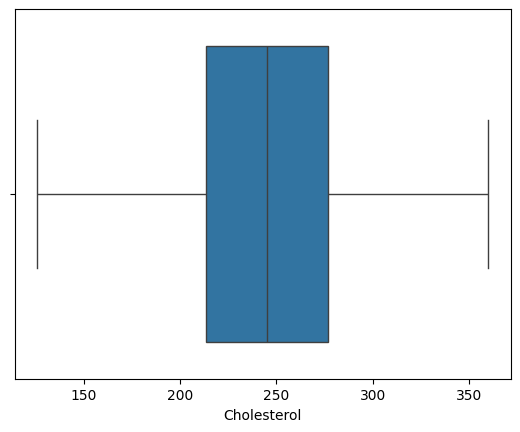

In [63]:
# check are there any outliers in Resting Bp
sns.boxplot(x=df_data1.Cholesterol)

In [64]:
# Handling Outliers
Q1=df_data1['Oldpeak'].quantile(0.25)
print("lower quartile",Q1)
Q3=df_data1['Oldpeak'].quantile(0.75)
print('upper quartile',Q3)

lower quartile 0.0
upper quartile 1.6


In [65]:
# Find IQR
IQR=Q3-Q1
IQR

np.float64(1.6)

In [66]:
# find  Lower limits and upper limit
lower_limit=Q1-1.5*IQR
print("lower limit is",lower_limit)
upper_limit=Q3+1.5*IQR
print("upper_limit",upper_limit)

lower limit is -2.4000000000000004
upper_limit 4.0


In [67]:
#Find values above upper_limit
df_data1.loc[df_data1['Oldpeak']>upper_limit]

,ST_Slope,thal,RestingBP,ChestPainType,NumMajoredVessels,FastingBS,RestingECG,Cholesterol,Oldpeak,sex,age,MaxHR,ExerciseAngina,HeartDisease
4,3,reversible_defect,130,1,0,0,2,270.0,4.2,1,59,145,0,0
112,2,reversible_defect,140,4,0,0,0,298.0,4.2,1,51,122,1,1
140,3,reversible_defect,140,4,0,0,0,217.0,5.6,1,55,111,1,1
162,3,reversible_defect,160,4,0,0,2,164.0,6.2,0,62,145,0,1


In [68]:
# Find percentage of outliers
len(df_data1.loc[df_data1['Oldpeak']>upper_limit])/len(data)

0.022222222222222223

In [69]:
# Find values below lower_limits
df_data1.loc[df_data1['Oldpeak']<lower_limit]

,ST_Slope,thal,RestingBP,ChestPainType,NumMajoredVessels,FastingBS,RestingECG,Cholesterol,Oldpeak,sex,age,MaxHR,ExerciseAngina,HeartDisease


In [70]:
df_data1.loc[df_data1['Oldpeak']>upper_limit,"Oldpeak"]=df_data1['Oldpeak'].median()

<Axes: xlabel='Oldpeak'>

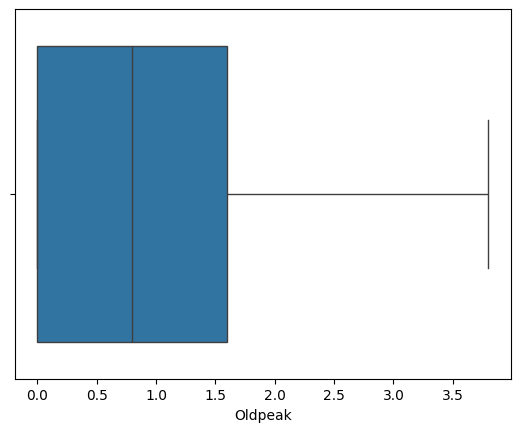

In [71]:
# check are there any outliers in Resting Bp
sns.boxplot(x=df_data1.Oldpeak)

# **SCALING**

In [72]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
df_data1[['RestingBP','Cholesterol','Oldpeak','MaxHR','age']]=scaler.fit_transform(df_data1[['RestingBP','Cholesterol','Oldpeak','MaxHR','age']])
df_data1

,ST_Slope,thal,RestingBP,ChestPainType,NumMajoredVessels,FastingBS,RestingECG,Cholesterol,Oldpeak,sex,age,MaxHR,ExerciseAngina,HeartDisease
0,1,normal,0.447368,2,0,0,2,0.777778,0.000000,1,0.333333,0.698113,0,0
1,2,normal,0.210526,3,0,0,0,0.376068,0.421053,0,0.520833,0.584906,0,0
2,1,normal,0.407895,4,0,0,2,0.760684,0.000000,1,1.000000,0.622642,1,1
3,1,reversible_defect,0.763158,4,0,0,0,0.414530,0.000000,1,0.229167,0.801887,0,1
4,3,reversible_defect,0.473684,1,0,0,2,0.615385,0.210526,1,0.625000,0.462264,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,2,reversible_defect,0.407895,4,2,1,0,0.547009,0.052632,1,0.791667,0.632075,0,1
176,2,normal,0.473684,4,0,0,1,0.858974,0.894737,0,0.541667,0.198113,1,1
177,2,reversible_defect,0.407895,3,0,0,0,0.782051,0.473684,1,0.729167,0.330189,1,1
178,1,normal,0.394737,3,2,1,0,0.551282,0.000000,1,0.395833,0.745283,0,0


# **Conversion of  Categorical variables**

In [73]:
df_data1.thal.unique()

array(['normal', 'reversible_defect', 'fixed_defect'], dtype=object)

In [74]:
df_data1.thal.value_counts()

,count
thal,
normal,98
reversible_defect,74
fixed_defect,8


In [75]:
df_data1['thal']=df_data1.thal.map({'normal':1, 'reversible_defect':2, 'fixed_defect':0})

In [76]:
df_data1.head(5)

,ST_Slope,thal,RestingBP,ChestPainType,NumMajoredVessels,FastingBS,RestingECG,Cholesterol,Oldpeak,sex,age,MaxHR,ExerciseAngina,HeartDisease
0,1,1,0.447368,2,0,0,2,0.777778,0.000000,1,0.333333,0.698113,0,0
1,2,1,0.210526,3,0,0,0,0.376068,0.421053,0,0.520833,0.584906,0,0
2,1,1,0.407895,4,0,0,2,0.760684,0.000000,1,1.000000,0.622642,1,1
3,1,2,0.763158,4,0,0,0,0.414530,0.000000,1,0.229167,0.801887,0,1
4,3,2,0.473684,1,0,0,2,0.615385,0.210526,1,0.625000,0.462264,0,0


In [77]:
df_data1.thal=df_data1.thal.astype('int64')
df_data1.dtypes

,0
ST_Slope,int64
thal,int64
RestingBP,float64
ChestPainType,int64
NumMajoredVessels,int64
FastingBS,int64
RestingECG,int64
Cholesterol,float64
Oldpeak,float64
sex,int64


# **Feature Engineering**

<Axes: >

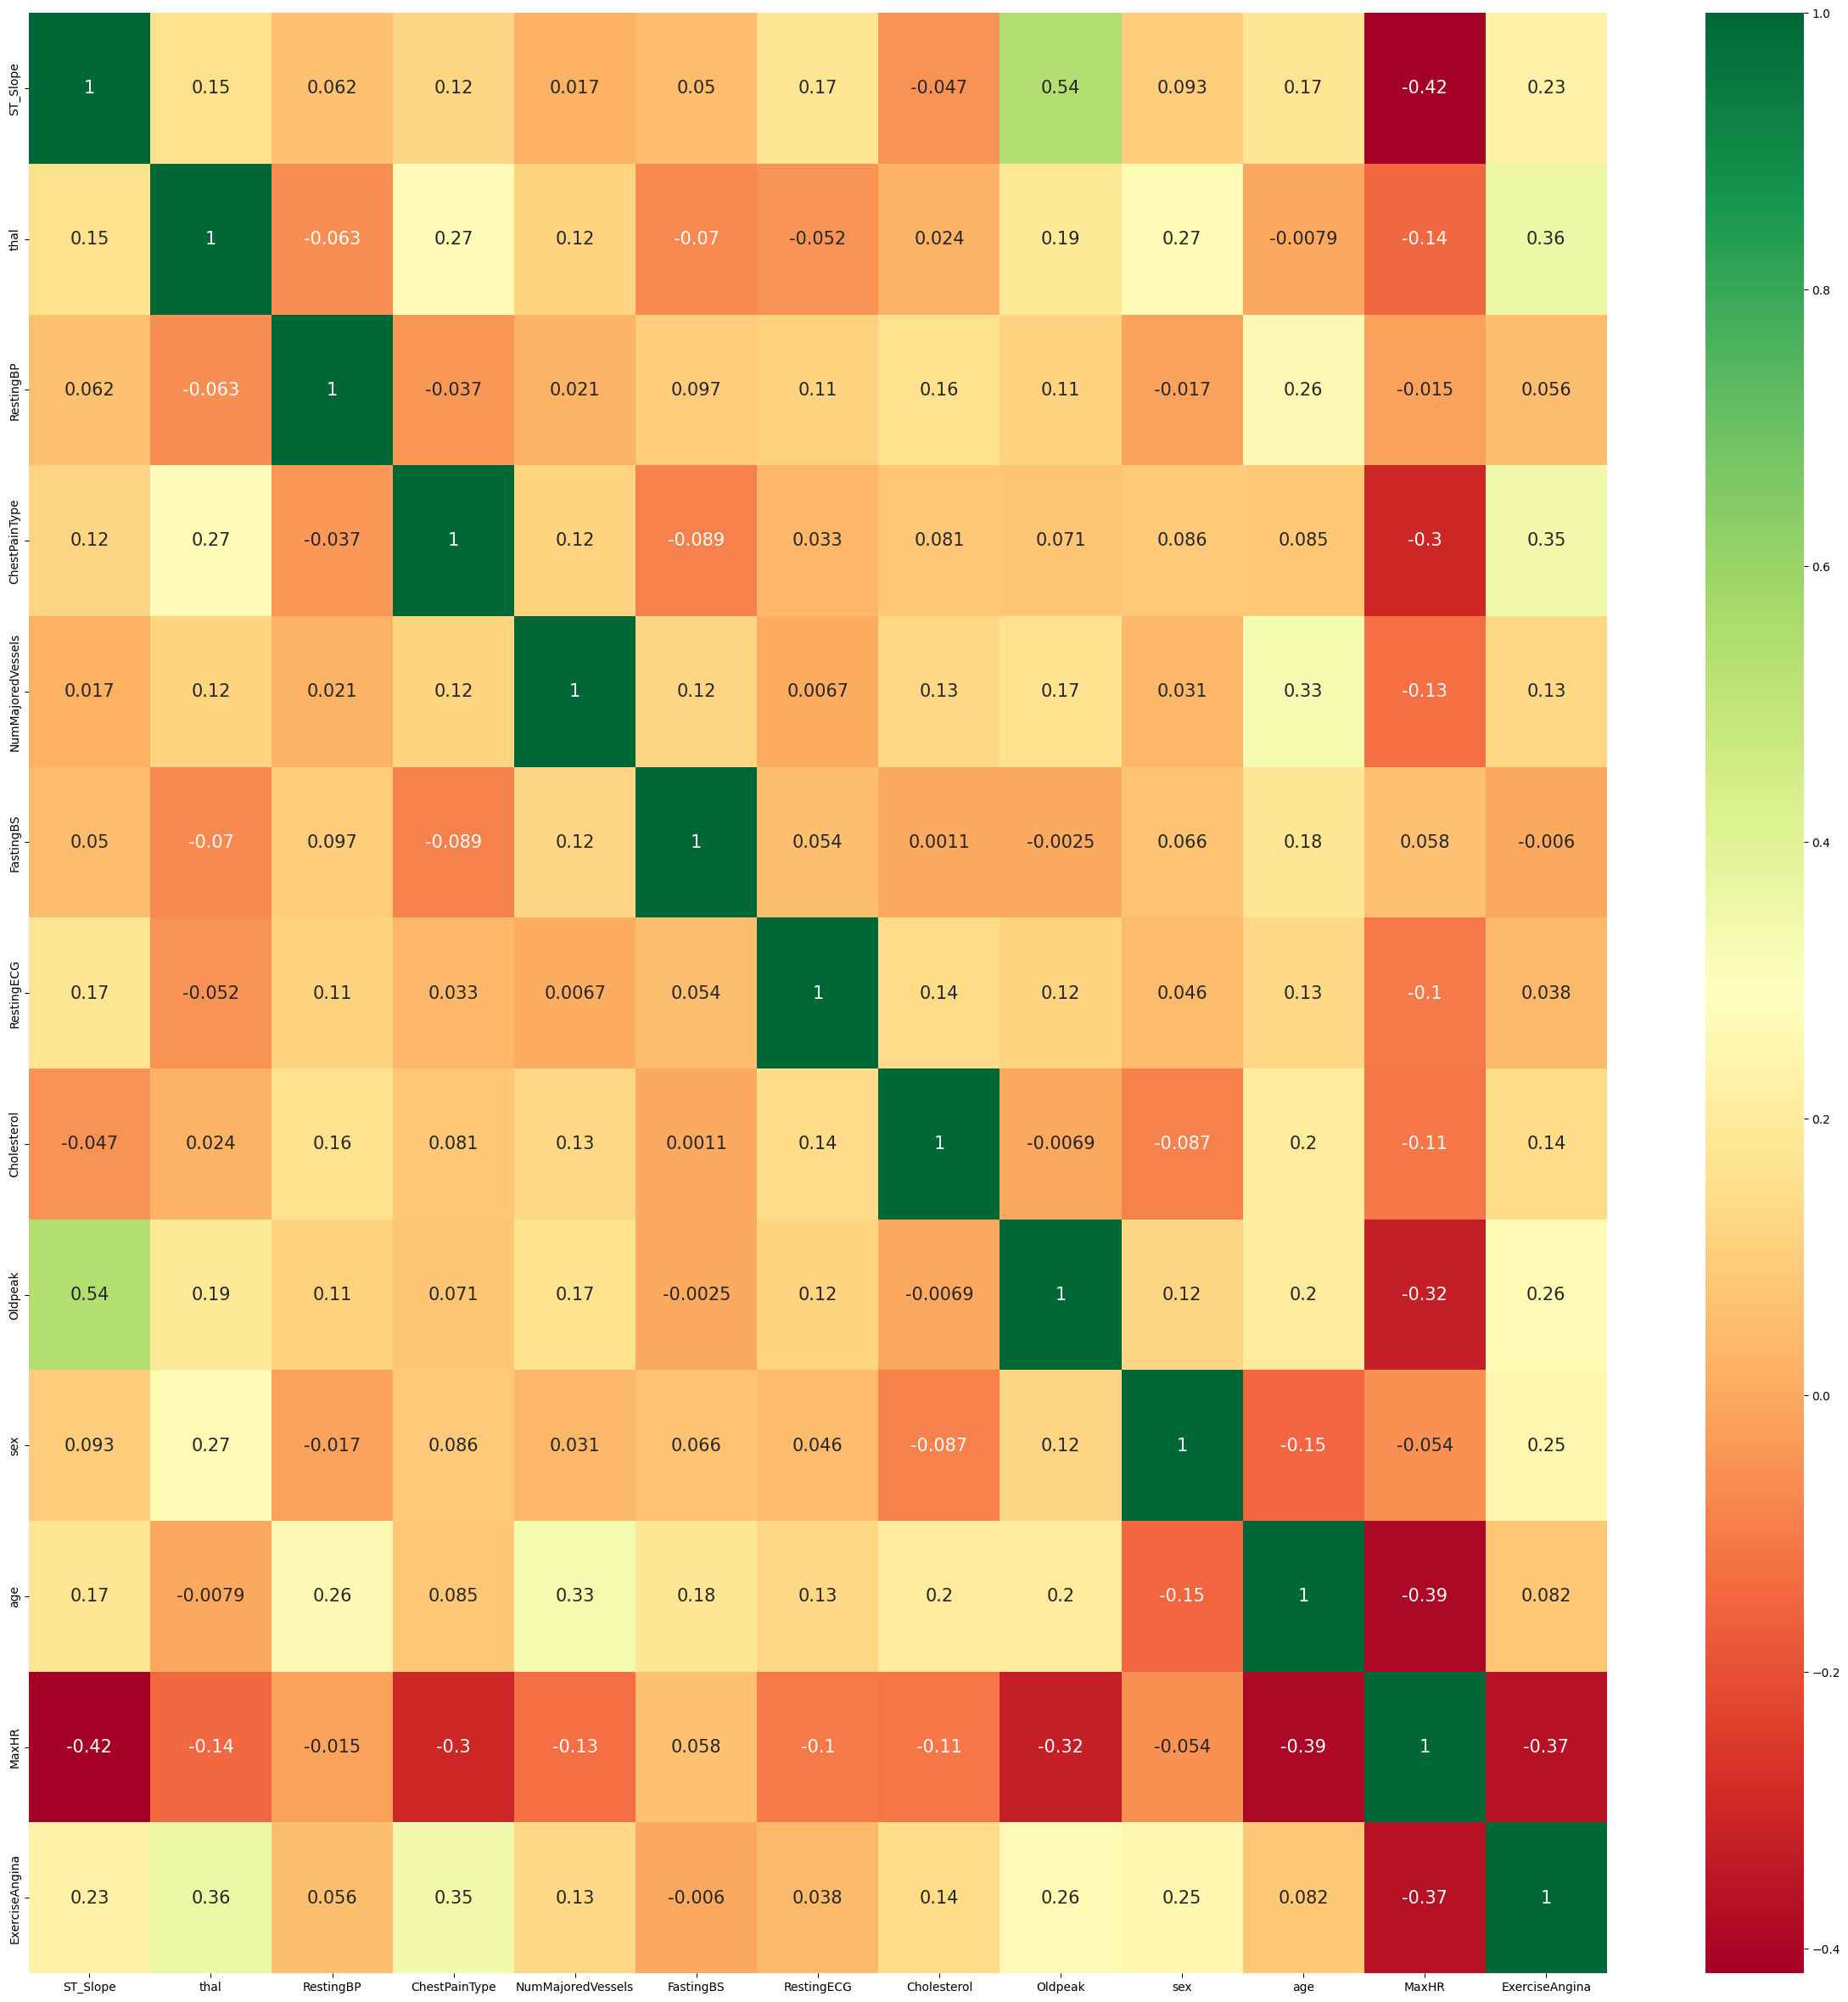

In [78]:
## Checking correlation
## Checking correlation

plt.figure(figsize=(30, 30))#canvas size
sns.heatmap(df_data1.drop('HeartDisease', axis=1).corr(), annot=True, cmap="RdYlGn", annot_kws={"size":15})#plotting heat map to check correlation

Observations:There is no highly correlated features

# **Model Creation**

In [79]:
x = df_data1.drop('HeartDisease', axis=1)
y = df_data1.HeartDisease#

In [80]:
# Split data for training and testing
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)


In [81]:
x_train.shape

(144, 13)

In [82]:
x_test.shape

(36, 13)

In [83]:
y_train.shape

(144,)

In [84]:
y_test.shape

(36,)

## 1.Logistic Regression Algorithm

In [85]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train,y_train)


LogisticRegression()

In [86]:
y_pred=model.predict(x_test)
y_pred

array([0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0])

In [87]:
y_train_pred=model.predict(x_train)
y_train_pred

array([0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1])

# **Model Evaluation for Logistic Algorithm**

In [88]:
# evaluate the model of LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,f1_score,recall_score,precision_score
pre_score_test=precision_score(y_test,y_pred)
print('pre_score_test:',pre_score_test)
recall_score_test=recall_score(y_test,y_pred)
print('recall_score_test:',recall_score_test)
acc_score_test=accuracy_score(y_test,y_pred)
print('acc_score_test:',acc_score_test)
f1_score=f1_score(y_test,y_pred)
print('f1_score:',f1_score)
acc_score_train=accuracy_score(y_train, y_train_pred)
print('acc_score_train:',acc_score_train)



pre_score_test: 1.0
recall_score_test: 0.7
acc_score_test: 0.8333333333333334
f1_score: 0.8235294117647058
acc_score_train: 0.8472222222222222


In [89]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.73      1.00      0.84        16
           1       1.00      0.70      0.82        20

    accuracy                           0.83        36
   macro avg       0.86      0.85      0.83        36
weighted avg       0.88      0.83      0.83        36



In [90]:
# model is overfitted since training score>testing score

## Cross validation

In [91]:
## checking cross validation score
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model,x,y,cv=3,scoring='accuracy')
print(scores)
print("Cross validation Score:",scores.mean())
print("Std :",scores.std())
#std of < 0.05 is good.

[0.81666667 0.81666667 0.83333333]
Cross validation Score: 0.8222222222222223
Std : 0.007856742013183886


# 2.Support Vector Machine Algorithm

In [92]:
## Support vector cLassifier model

from sklearn.svm import SVC
svclassifier = SVC() ## base model with default parameters
svclassifier.fit(x_train , y_train)

SVC()

In [93]:
y_predSVM = svclassifier.predict(x_test)
y_predSVM

array([0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0])

In [94]:
y_train_predSVM = svclassifier.predict(x_train)
y_train_predSVM


array([1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1])

In [95]:
#Model Evaluation
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,f1_score,recall_score,precision_score

In [96]:
pre_test_svm=precision_score(y_test,y_predSVM)
print('pre_score_test:',pre_score_test)
recall_test_svm=recall_score(y_test,y_predSVM)
print('recall_score_test:',recall_score_test)
f1_test_svm=f1_score(y_test,y_predSVM)
print('f1_score:',f1_test_svm)
acc_score_testSVM=accuracy_score(y_test,y_predSVM)
print('acc_score_test:',acc_score_testSVM)
acc_score_trainSVM=accuracy_score(y_train, y_train_predSVM)
print('acc_score_train:',acc_score_trainSVM)



pre_score_test: 1.0
recall_score_test: 0.7
f1_score: 0.8888888888888888
acc_score_test: 0.8888888888888888
acc_score_train: 0.8680555555555556


In [97]:
cl_SVM=classification_report(y_test,y_predSVM)

In [98]:
cl_SVM

'              precision    recall  f1-score   support\n\n           0       0.80      1.00      0.89        16\n           1       1.00      0.80      0.89        20\n\n    accuracy                           0.89        36\n   macro avg       0.90      0.90      0.89        36\nweighted avg       0.91      0.89      0.89        36\n'

# Hyperparameter tuning

In [99]:
## Hyperparameter Tuning
# grid search CV
from sklearn.model_selection import GridSearchCV
# define hyperparamter range
param_grid={'C':[0.1,5,10,50,60,70],'gamma':[1,0.1,0.01,0.001,0.001],'random_state':list(range(1,20))}
model_HT=SVC()
grid=GridSearchCV(model_HT,param_grid,verbose=2,scoring="accuracy",cv=5)
grid.fit(x,y)

Fitting 5 folds for each of 570 candidates, totalling 2850 fits
[CV] END .....................C=0.1, gamma=1, random_state=1; total time=   0.0s
[CV] END .....................C=0.1, gamma=1, random_state=1; total time=   0.0s
[CV] END .....................C=0.1, gamma=1, random_state=1; total time=   0.0s
[CV] END .....................C=0.1, gamma=1, random_state=1; total time=   0.0s
[CV] END .....................C=0.1, gamma=1, random_state=1; total time=   0.0s
[CV] END .....................C=0.1, gamma=1, random_state=2; total time=   0.0s
[CV] END .....................C=0.1, gamma=1, random_state=2; total time=   0.0s
[CV] END .....................C=0.1, gamma=1, random_state=2; total time=   0.0s
[CV] END .....................C=0.1, gamma=1, random_state=2; total time=   0.0s
[CV] END .....................C=0.1, gamma=1, random_state=2; total time=   0.0s
[CV] END .....................C=0.1, gamma=1, random_state=3; total time=   0.1s
[CV] END .....................C=0.1, gamma=1,

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 5, 10, 50, 60, 70],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.001],
                         'random_state': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                          13, 14, 15, 16, 17, 18, 19]},
             scoring='accuracy', verbose=2)

In [100]:
# print best parameter after tuning
print(grid.best_params_)
# print how our model looks after hyper-parameter tuning
#print(grid.best_estimator_)

{'C': 5, 'gamma': 0.1, 'random_state': 1}


In [101]:
model_HT=SVC(C=5,gamma=0.1,random_state=1)
model_HT.fit(x_test,y_test)

SVC(C=5, gamma=0.1, random_state=1)

In [102]:
y_SVM_HT=model_HT.predict(x_test)
y_SVM_HT

array([1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0])

In [103]:
pre_testSVM_HT=precision_score(y_test,y_SVM_HT)
print('pre_score_test:',pre_testSVM_HT)
recall_testSVM_HT=recall_score(y_test,y_SVM_HT)
print('recall_score_test:',recall_testSVM_HT)
f1_testSVM_HT=f1_score(y_test,y_SVM_HT)
print('f1_score:',f1_testSVM_HT)
acc_score_testSVM_HT=accuracy_score(y_test,y_SVM_HT)
print('acc_score_test:',acc_score_testSVM_HT)



pre_score_test: 0.9473684210526315
recall_score_test: 0.9
f1_score: 0.9230769230769231
acc_score_test: 0.9166666666666666


## 3.Decision Tree Algorithm

In [104]:
from sklearn.tree import DecisionTreeClassifier#importing decision tree from sklearn.tree
dt=DecisionTreeClassifier()#object creation for decision tree
dt.fit(x_train,y_train)#training the model
y_hat=dt.predict(x_test)#prediction
y_hat#predicted values

array([0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0])

In [105]:
y_train_pred_DT=dt.predict(x_train)#predicting training data to check training performance
y_train_pred_DT

array([1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1])

In [106]:
pre_test_DT=precision_score(y_test,y_hat)
print('pre_score_test:',pre_test_DT)
recall_test_DT=recall_score(y_test,y_hat)
print('recall_score_test:',recall_test_DT)
f1_test_DT=f1_score(y_test,y_hat)
print('f1_score:',f1_test_DT)
acc_score_testDT=accuracy_score(y_test,y_hat)
print('accuracy_score_test:',acc_score_testDT)
acc_train_DT=accuracy_score(y_train,y_train_pred_DT)#checking accuracy
print('accuracy_train:',acc_train_DT)

pre_score_test: 0.9333333333333333
recall_score_test: 0.7
f1_score: 0.8
accuracy_score_test: 0.8055555555555556
accuracy_train: 1.0


In [107]:
print(classification_report(y_train,y_train_pred_DT))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        84
           1       1.00      1.00      1.00        60

    accuracy                           1.00       144
   macro avg       1.00      1.00      1.00       144
weighted avg       1.00      1.00      1.00       144



In [108]:
pd.crosstab(y_train,y_train_pred_DT)

col_0,0,1
HeartDisease,,
0,84,0
1,0,60


In [109]:
test_acc_DT=accuracy_score(y_test,y_hat)#testing accuracy
test_acc_DT

0.8055555555555556

In [110]:
print(classification_report(y_test,y_hat))# for  testing

              precision    recall  f1-score   support

           0       0.71      0.94      0.81        16
           1       0.93      0.70      0.80        20

    accuracy                           0.81        36
   macro avg       0.82      0.82      0.81        36
weighted avg       0.84      0.81      0.80        36



In [111]:
pd.crosstab(y_test,y_hat)

col_0,0,1
HeartDisease,,
0,15,1
1,6,14


In [112]:
## Cross validation
# checking cross validation score
from sklearn.model_selection import cross_val_score
scores = cross_val_score(dt,x,y,cv=5,scoring='accuracy')
print(scores)
print("Cross validation Score:",scores.mean())
print("Std :",scores.std())
#std of < 0.05 is good.

[0.66666667 0.72222222 0.75       0.63888889 0.72222222]
Cross validation Score: 0.7
Std : 0.04082482904638632


In [113]:
## HyperParameter Tuning
params = {
    "criterion":("gini", "entropy"), #quality of split
    "splitter":("best", "random"), # searches the features for a split
    "max_depth":(list(range(1, 20))), #depth of tree range from 1 to 19
    "min_samples_split":[2, 3, 4],    #the minimum number of samples required to split internal node
    "min_samples_leaf":list(range(1, 20)),#minimum number of samples required to be at a leaf node,we are passing list which is range from 1 to 19
}
tree_clf = DecisionTreeClassifier(random_state=3)#object creation for decision tree with random state 3
tree_cv = GridSearchCV(tree_clf, params, scoring="accuracy", n_jobs=-1, verbose=1, cv=3)
tree_cv.fit(x_train,y_train)#training data on gridsearch cv
best_params = tree_cv.best_params_#it will give you best parameters
print(f"Best paramters: {best_params})")#printing  best parameters

Fitting 3 folds for each of 4332 candidates, totalling 12996 fits
Best paramters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 7, 'min_samples_split': 2, 'splitter': 'random'})


In [114]:
tree_cv.best_params_

{'criterion': 'gini',
 'max_depth': 5,
 'min_samples_leaf': 7,
 'min_samples_split': 2,
 'splitter': 'random'}

In [115]:
tree_cv.best_score_#getting best score form cv

np.float64(0.8055555555555555)

In [116]:
dt1=DecisionTreeClassifier(criterion='gini',max_depth=2,min_samples_leaf= 4,min_samples_split=2,splitter='random')#passing best parameter to decision tree

In [117]:
dt1.fit(x_train,y_train)#traing model with best parameter

DecisionTreeClassifier(max_depth=2, min_samples_leaf=4, splitter='random')

In [118]:
y_hat1=dt1.predict(x_test)#predicting
y_hat1

array([0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0])

In [119]:
pre_testDT_HT=precision_score(y_test,y_hat1)
print('pre_score_test:',pre_testDT_HT)
recall_testDT_HT=recall_score(y_test,y_hat1)
print('recall_score_test:',recall_testDT_HT)
f1_testDT_HT=f1_score(y_test,y_hat1)
print('f1_score:',f1_testDT_HT)
acc_test_DT=accuracy_score(y_test,y_hat1)#checking accuracy
print('acc_score:',acc_test_DT)

pre_score_test: 1.0
recall_score_test: 0.45
f1_score: 0.6206896551724138
acc_score: 0.6944444444444444


In [120]:
print(classification_report(y_test,y_hat1))#it will give precision,recall,f1 scores and accuracy

              precision    recall  f1-score   support

           0       0.59      1.00      0.74        16
           1       1.00      0.45      0.62        20

    accuracy                           0.69        36
   macro avg       0.80      0.72      0.68        36
weighted avg       0.82      0.69      0.68        36



## 4.Random Forest

In [121]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(x_train,y_train)
y_pred_rf=rf.predict(x_test)
y_pred_rf

array([0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0])

In [122]:
y_train_pred_rf=rf.predict(x_train)
y_train_pred_rf

array([1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1])

In [123]:
pre_test_rf=precision_score(y_test,y_pred_rf)
print('pre_score_test:',pre_test_rf)
recall_test_rf=recall_score(y_test,y_pred_rf)
print('recall_score_test:',recall_test_rf)
f1_test_rf=f1_score(y_test,y_pred_rf)
print('f1_score:',f1_test_rf)
acc_rf=accuracy_score(y_test,y_pred_rf)
print('accuracy_score:',acc_rf)
acc_train_rf=accuracy_score(y_train,y_train_pred_rf)
acc_train_rf

pre_score_test: 1.0
recall_score_test: 0.7
f1_score: 0.8235294117647058
accuracy_score: 0.8333333333333334


1.0

In [124]:
cl_rf=classification_report(y_test,y_pred_rf)
cl_rf

'              precision    recall  f1-score   support\n\n           0       0.73      1.00      0.84        16\n           1       1.00      0.70      0.82        20\n\n    accuracy                           0.83        36\n   macro avg       0.86      0.85      0.83        36\nweighted avg       0.88      0.83      0.83        36\n'

In [125]:
# Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV
n_estimators = [int(x) for x in np.linspace(start=200, stop=2000, num=10)]
max_features = ['auto', 'sqrt']
max_depth = [int(x) for x in np.linspace(10, 110, num=11)]
max_depth.append(None)
min_samples_split = [2, 5, 10]
min_samples_leaf = [1, 2, 4]
bootstrap = [True, False]

random_grid= {'n_estimators': n_estimators, 'max_features': max_features,
               'max_depth': max_depth, 'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf, 'bootstrap': bootstrap}

rf_clf1 = RandomForestClassifier(random_state=42)

rf_cv = RandomizedSearchCV(estimator=rf_clf1, scoring='accuracy',param_distributions=random_grid, n_iter=100, cv=3,
                               verbose=2, random_state=42, n_jobs=-1)

rf_cv.fit(x_train, y_train)
rf_best_params = rf_cv.best_params_
print(f"Best paramters: {rf_best_params})")

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best paramters: {'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': True})


In [126]:
rf_clf2 = RandomForestClassifier(n_estimators=400 , min_samples_split=5 , min_samples_leaf= 1, max_features= 'sqrt', max_depth=30, bootstrap=True )
rf_clf2.fit(x_train, y_train)
y_rf_pred=rf_clf2.predict(x_test)
y_rf_pred

array([0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0])

In [127]:
pre_testrf_HT=precision_score(y_test,y_rf_pred)
print('pre_score_test:',pre_testrf_HT)
recall_testrf_HT=recall_score(y_test,y_rf_pred)
print('recall_score_test:',recall_testrf_HT)
f1_testrf_HT=f1_score(y_test,y_rf_pred)
print('f1_score:',f1_testrf_HT)
acc_test_rf_HT=accuracy_score(y_test,y_rf_pred)#checking accuracy
print('acc_score:',acc_test_rf_HT)

pre_score_test: 0.9375
recall_score_test: 0.75
f1_score: 0.8333333333333334
acc_score: 0.8333333333333334


## 5.KNN

In [128]:
from sklearn.neighbors import KNeighborsClassifier
KNN= KNeighborsClassifier(n_neighbors=7)
KNN.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=7)

In [129]:
y_pred_knn=KNN.predict(x_test)

In [130]:
pre_test_knn=precision_score(y_test,y_pred_knn)
print('pre_score_test:',pre_test_knn)
recall_test_knn=recall_score(y_test,y_pred_knn)
print('recall_score_test:',recall_test_knn)
f1_test_knn=f1_score(y_test,y_pred_knn)
print('f1_score:',f1_test_knn)
KNN_acc=accuracy_score(y_test,y_pred_knn)
print('accuracy_score:',KNN_acc)

pre_score_test: 1.0
recall_score_test: 0.8
f1_score: 0.8888888888888888
accuracy_score: 0.8888888888888888


In [131]:
KNN_acc_train=accuracy_score(y_train,KNN.predict(x_train))
KNN_acc_train

0.8333333333333334

## 6.XGBOOST

In [132]:
from xgboost import XGBClassifier
xgb_m = XGBClassifier()
xgb_m.fit(x_train, y_train)

y_pred_XGB = xgb_m.predict(x_test)
y_pred_XGB

array([0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0])

In [133]:
pre_test_XGB=precision_score(y_test,y_pred_XGB)
print('pre_score_test:',pre_test_XGB)
recall_test_XGB=recall_score(y_test,y_pred_XGB)
print('recall_score_test:',recall_test_XGB)
f1_test_XGB=f1_score(y_test,y_pred_XGB)
print('f1_score:',f1_test_XGB)
XGB_acc=accuracy_score(y_test,y_pred_XGB)
print('accuracy_score:',XGB_acc)

pre_score_test: 0.8823529411764706
recall_score_test: 0.75
f1_score: 0.8108108108108109
accuracy_score: 0.8055555555555556


In [134]:
# Hyperparamter tuning for XGBoost
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# Define the model
xgb_m = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.2],
    'min_child_weight': [1, 3, 5]
}

# Setup GridSearchCV
grid_search = GridSearchCV(estimator=xgb_m,
                           param_grid=param_grid,
                           scoring='accuracy',  # You can also use 'accuracy', 'recall', etc.
                           cv=3,          # 3-fold cross-validation
                           verbose=1,
                           n_jobs=-1)

# Fit
grid_search.fit(x_train, y_train)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)

# Best model
best_xgb = grid_search.best_estimator_

# Predict
y_pred_XGB_best = best_xgb.predict(x_test)

# Evaluation
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

pre_test_XGB_HT = precision_score(y_test, y_pred_XGB_best)
print('Precision:', pre_test_XGB_HT)
recall_test_XGB_HT = recall_score(y_test, y_pred_XGB_best)
print('Recall:', recall_test_XGB_HT)
f1_test_XGB_HT = f1_score(y_test, y_pred_XGB_best)
print('F1-score:', f1_test_XGB_HT)
XGB_acc_HT = accuracy_score(y_test, y_pred_XGB_best)
print('Accuracy:', XGB_acc_HT)


Fitting 3 folds for each of 972 candidates, totalling 2916 fits
Best parameters found:  {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 1.0}
Precision: 0.9375
Recall: 0.75
F1-score: 0.8333333333333334
Accuracy: 0.8333333333333334


In [135]:
!pip install tabulate

In [136]:
from tabulate import tabulate

In [137]:
Table = [["LR", pre_score_test,recall_score_test,acc_score_test,f1_score],
        ["SVM", pre_test_svm,recall_test_svm,acc_score_testSVM,f1_test_svm],
        ["SVM_HT", pre_testSVM_HT,recall_testSVM_HT,acc_score_testSVM_HT,f1_testSVM_HT],
        ["XGBoost", pre_test_XGB,recall_test_XGB,XGB_acc,f1_test_XGB],
        ["XGBoost_HT", pre_test_XGB_HT,recall_test_XGB_HT,XGB_acc_HT,f1_test_XGB_HT],
        ["Decision Tree", pre_test_DT,recall_test_DT,acc_score_testDT,f1_test_DT],
        ["Decision Tree_HT", pre_testDT_HT,recall_testDT_HT,acc_test_DT,f1_testDT_HT],
        ["Random Forest", pre_test_rf,recall_test_rf,acc_rf,f1_test_rf],
        ["Random Forest_HT", pre_testrf_HT,recall_testrf_HT,acc_test_rf_HT,f1_testrf_HT],
        ["KNN", pre_test_knn,recall_test_knn,KNN_acc,f1_test_knn]]

col_names1 = ["Algorithm", "Precision Score", "recall Score", "Accuracy Score", "F1 Score"]

print(tabulate(Table, headers = col_names1, tablefmt = "fancy_grid"))


╒══════════════════╤═══════════════════╤════════════════╤══════════════════╤═══════════════════════════════════════╕
│ Algorithm        │   Precision Score │   recall Score │   Accuracy Score │ F1 Score                              │
╞══════════════════╪═══════════════════╪════════════════╪══════════════════╪═══════════════════════════════════════╡
│ LR               │          1        │           0.7  │         0.833333 │ <function f1_score at 0x7912930cf920> │
├──────────────────┼───────────────────┼────────────────┼──────────────────┼───────────────────────────────────────┤
│ SVM              │          1        │           0.8  │         0.888889 │ 0.8888888888888888                    │
├──────────────────┼───────────────────┼────────────────┼──────────────────┼───────────────────────────────────────┤
│ SVM_HT           │          0.947368 │           0.9  │         0.916667 │ 0.9230769230769231                    │
├──────────────────┼───────────────────┼────────────────┼───────

# **Conclusion**
SVM(classifier) Algorithm and KNN model  performed the best out of all the algorithms for Heart disease prediction data set.
Both Knn and SVM shows highest Accuracy scores and F1 score
.
